In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as transforms
import os

In [2]:
hancock_df = pd.read_csv("../data/HANCOCK_imputation_checkpoint_results.csv")
hancock_df["na_ratio"] = hancock_df["na_ratio"].astype(str)
hancock_df.sort_values(by="na_ratio", inplace=True)
luad_df = pd.read_csv("../data/TCGA_LUAD_imputation_checkpoint_results.csv")
luad_df["na_ratio"] = luad_df["na_ratio"].astype(str)
luad_df.sort_values(by="na_ratio", inplace=True)
mimic_df = pd.read_csv("../data/MIMIC_imputation_checkpoint_results.csv")
mimic_df["na_ratio"] = mimic_df["na_ratio"].astype(str)
mimic_df.sort_values(by="na_ratio", inplace=True)
all_df = pd.concat([hancock_df, luad_df, mimic_df], ignore_index=True)
hancock_df

,run,na_ratio,epoch,mae_cont,acc_cat,dataset
199,5,0.01,100,204.070231,0.806604,HANCOCK
44,8,0.01,400,213.040309,0.871495,HANCOCK
173,6,0.01,1000,170.420088,0.879908,HANCOCK
170,9,0.01,700,174.437896,0.856813,HANCOCK
57,5,0.01,700,194.996900,0.837264,HANCOCK
...,...,...,...,...,...,...
109,5,0.5,100,174.468186,0.860604,HANCOCK
174,8,0.5,400,177.235757,0.861550,HANCOCK
47,5,0.5,700,175.473532,0.867354,HANCOCK
68,1,0.5,100,176.638392,0.859641,HANCOCK


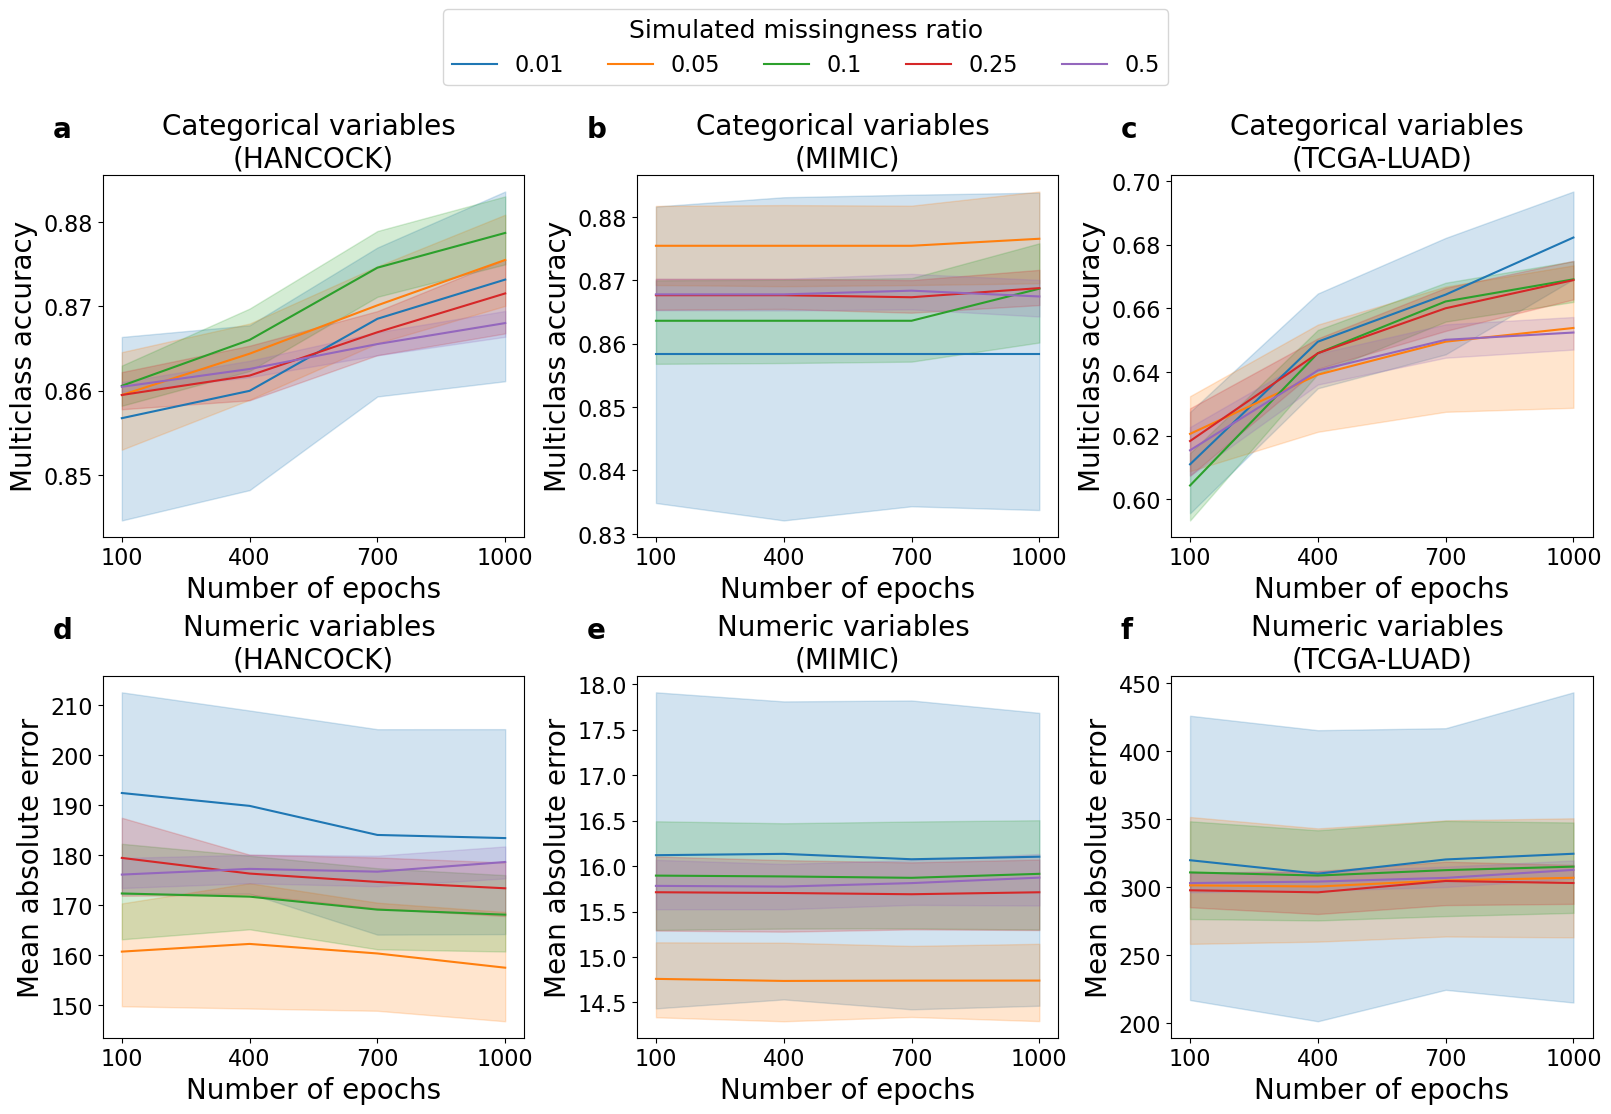

In [3]:
mosaic = [
['a', 'b', 'c'], ['d', 'e', 'f']
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16,10), layout='constrained')

offset = transforms.ScaledTranslation(-36/72, 27/72, fig.dpi_scale_trans)
labelfontsize = 20
titlefontsize = 20
ticklabelsize = 16
xylabelsize = 18
legendfontsize = 16
legendtitlefontsize = 18
pvalfontsize = 18

sns.set_palette(sns.color_palette("tab10"))

sns.lineplot(data=hancock_df, x="epoch", y="acc_cat", hue="na_ratio", ax=axes['a'])
axes['a'].set_xlabel('Number of epochs', fontsize=labelfontsize) 
axes['a'].set_ylabel('Multiclass accuracy', fontsize=labelfontsize) 
axes['a'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['a'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['a'].set_xticks([100, 400, 700, 1000])
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['a'].set_title("Categorical variables \n(HANCOCK)", fontsize=titlefontsize)
axes['a'].text(0.0, 1.0, 'a', transform=axes['a'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# get handles + labels from axes['a']
handles, labels = axes['a'].get_legend_handles_labels()

# remove the original legend from axes['a']
axes['a'].legend_.remove()

# add a figure-level legend on top
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.11),  # adjust height here
    ncol=len(labels)+1,            # or set a fixed number of columns
    fontsize=legendfontsize,
    title="Simulated missingness ratio",
    title_fontsize=legendtitlefontsize
)

sns.lineplot(data=mimic_df, x="epoch", y="acc_cat", hue="na_ratio", ax=axes['b'], legend=False)
axes['b'].set_xlabel('Number of epochs', fontsize=labelfontsize) 
axes['b'].set_ylabel('Multiclass accuracy', fontsize=labelfontsize) 
axes['b'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['b'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['b'].set_xticks([100, 400, 700, 1000])
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['b'].set_title("Categorical variables \n(MIMIC)", fontsize=titlefontsize)
axes['b'].text(0.0, 1.0, 'b', transform=axes['b'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.lineplot(data=luad_df, x="epoch", y="acc_cat", hue="na_ratio", ax=axes['c'], legend=False)
axes['c'].set_xlabel('Number of epochs', fontsize=labelfontsize) 
axes['c'].set_ylabel('Multiclass accuracy', fontsize=labelfontsize) 
axes['c'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['c'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['c'].set_xticks([100, 400, 700, 1000])
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['c'].set_title("Categorical variables \n(TCGA-LUAD)", fontsize=titlefontsize)
axes['c'].text(0.0, 1.0, 'c', transform=axes['c'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.lineplot(data=hancock_df, x="epoch", y="mae_cont", hue="na_ratio", ax=axes['d'], legend=False)
axes['d'].set_xlabel('Number of epochs', fontsize=labelfontsize) 
axes['d'].set_ylabel('Mean absolute error', fontsize=labelfontsize) 
axes['d'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['d'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['d'].set_xticks([100, 400, 700, 1000])
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['d'].set_title("Numeric variables \n(HANCOCK)", fontsize=titlefontsize)
axes['d'].text(0.0, 1.0, 'd', transform=axes['d'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.lineplot(data=mimic_df, x="epoch", y="mae_cont", hue="na_ratio", ax=axes['e'], legend=False)
axes['e'].set_xlabel('Number of epochs', fontsize=labelfontsize) 
axes['e'].set_ylabel('Mean absolute error', fontsize=labelfontsize) 
axes['e'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['e'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['e'].set_xticks([100, 400, 700, 1000])
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['e'].set_title("Numeric variables \n(MIMIC)", fontsize=titlefontsize)
axes['e'].text(0.0, 1.0, 'e', transform=axes['e'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.lineplot(data=luad_df, x="epoch", y="mae_cont", hue="na_ratio", ax=axes['f'], legend=False)
axes['f'].set_xlabel('Number of epochs', fontsize=labelfontsize) 
axes['f'].set_ylabel('Mean absolute error', fontsize=labelfontsize) 
axes['f'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['f'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['f'].set_xticks([100, 400, 700, 1000])
#axes['b'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['f'].set_title("Numeric variables \n(TCGA-LUAD)", fontsize=titlefontsize)
axes['f'].text(0.0, 1.0, 'f', transform=axes['f'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

plt.savefig("supplement_imputation_per_epoch.pdf", bbox_inches='tight')